# HIXL 单边通信库介绍
在上一节中，我们介绍了单边通信的基本原理和核心优势。从本节开始，我们将深入学习昇腾单边通信库 HIXL 的核心组件、开发流程以及关键特性，并全面了解 HIXL 提供的核心编程接口（API）的使用方式。这些理论知识将为后续实际开发高性能数据传输应用奠定坚实基础。

本节学习大纲如下：

- HIXL 功能概述
- HIXL 软件架构
- HIXL 使用场景
- 实测性能 Benchmark


## 1. HIXL 功能概述
HIXL（Huawei Xfer Library）是一个灵活、高效的昇腾单边通信库，面向集群场景提供简单、可靠、高效的点对点数据传输能力，并通过简易 API 开放给用户, 在多 AI 应用和多传输链路之间建立了桥梁。

### 1.1 核心优势
- **支持单边零拷贝（One-Sided Zero-Copy）通信机制**：HIXL 提供简易、可靠的单边通信接口，单边零拷贝完成远端数据传输，无需远端参与，为用户构建通信与计算重叠掩盖的调度机制提供核心技术能力。同时，零拷贝能力实现用户内存间的直接数据传输，避免冗余数据搬运，不仅可以降低内存带宽占用，还可以减少内存容量消耗。

<img src="./images/oneside_zerocopy.png" alt="HIXL 单边零拷贝" width="50%">

- **屏蔽硬件差异，兼容多链路实现跨设备高速互联**：HIXL 屏蔽了昇腾系列芯片的底层硬件差异，用户无需针对不同芯片架构进行代码适配。在通信链路层面，该技术原生支持 RDMA，HCCS 等多种高速互联协议，可实现跨架构设备（如 A2 系列与 A3 系列昇腾芯片）的无缝高速互联，满足低时延、 高吞吐的需求。

<img src="./images/multi_highspeed_link.png" alt="HIXL 多链路高速互连" width="60%">

- **极简 API 设计，深度适配开源生态框架**：HIXL 采用极简式 API 接口设计，降低开发者集成门槛。目前已实现与 Mooncake、DeepLink 等开源框架的深度集成，vLLM、SGLang 等主流推理引擎也可以直接调用 HIXL API 完成 KV Cache 的跨设备高效传输。

<img src="./images/third_party_integration.png" alt="HIXL 多链路高速互连" width="60%">

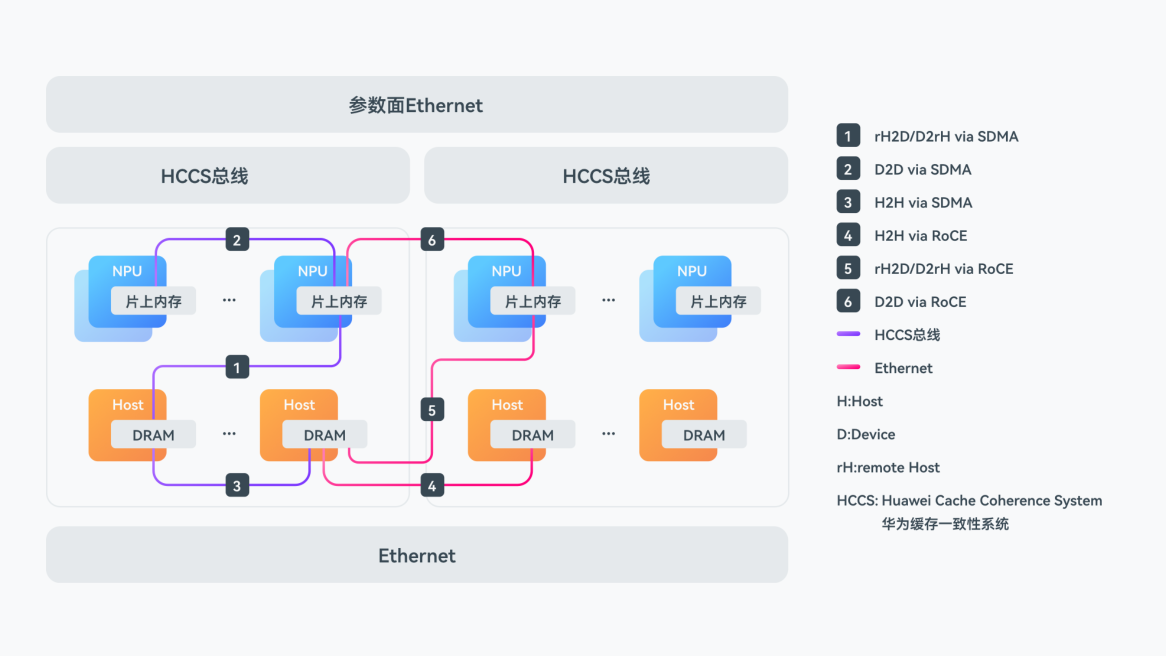

## 2. 软件架构
HIXL 单边通信库的软件架构图如下：

<img src="./images/official_hixl_architecture_layers.png" alt="HIXL 架构层次图" width="60%">

**核心组件**

- **HIXL Engine**：作为核心传输引擎，提供了基础传输接口，支持多种类型内存类型传输，比如 D2D、D2H、H2D。同时兼容多种传输协议，包括 HCCS、RDMA 等。可实现高速、可靠的数据传输。原生支持多类型数据链路，可灵活同构集群、异构集群的复杂场景。面对集群节点动态扩缩容需求时，可快速完成链路适配与资源调度，为集群整体运行构建可靠通信基础。

- **LLM-DataDist**：基于 HIXL Engine 构建，提供了一套携带 KV Cache 语义的数据传输接口。可快速、灵活对接 vLLM、SGLang 等推理引擎。

> 本课程内容聚焦 HIXL Engine 相关内容，对 LLM-DataDist 不做过多介绍，可以将其理解为 HIXL 接口在大模型训推 PD 分离场景下的语义封装和优秀实践。


## 3. HIXL 常见应用场景

- **大模型 PD 分离**：将 Prefill（预填充）和 Decode（解码）阶段分离到不同设备，实现计算与通信重叠，提升推理吞吐，通过 HIXL 实现 P/D 节点之间的 KV Cache 传输。

<img src="./images/pd_separation.png" alt="大模型 PD 分离" width="80%">

- **KV Cache 跨设备分层传输**：对接 vLLM、SGLang 等主流推理引擎，在多请求和多轮会话场景下，实现 KV 池化多级存储设备间 KV Cache 高效传输，大幅降低 TTFT（首 token 推理时延）。

<img src="./images/kv_cache_transfer.png" alt="KV Cache分层传输" width="80%">

- **RL 后训练参数切换**：强化学习后训练阶段的模型参数快速切换场景，极大缩短训推切换过程中参数更新的耗时。

<img src="./images/rl_param_switch.png" alt="后训练参数更新" width="50%">

除上述几种场景外，HIXL 还可以用于模型参数 offload/reload、小数据批量异步传输，模型知识库数据传输等需要高性能数据传输的场景。


## 4. 实测 Benchmark 性能

为了让你对不同通信链路的带宽建立直观的感受，本节展示了 HIXL 在 昇腾 Atlas A2/A3 服务器上实测的基准性能数据，同时说明了当前不同服务器的底层通信链路的支持情况。

### 4.1 Atlas A2 场景性能

#### 4.1.1 单机场景能

| **Block** | **D2rD<br>HCCS** | **D2rD<br>ROCE** | **D2rH<br>HCCS** | **D2rH<br>ROCE** | **H2rH<br>HCCS** | **H2rH<br>ROCE** | **H2rD<br>HCCS** | **H2rD<br>ROCE** | **rD2D<br>HCCS** | **rD2D<br>ROCE** | **rH2D<br>HCCS** | **rH2D<br>ROCE** | **rH2H<br>HCCS** | **rH2H<br>ROCE** | **rD2H<br>HCCS** | **rD2H<br>ROCE** |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 16K | 1.47 | 0.716 | 不支持 | 0.698 | 不支持 | 0.713 | 不支持 | 0.722 | 1.387 | 0.701 | 不支持 | 0.698 | 不支持 | 0.699 | 不支持 | 0.678 |
| 32K | 2.493 | 1.42 | 不支持 | 1.43 | 不支持 | 1.421 | 不支持 | 1.409 | 2.744 | 1.397 | 不支持 | 1.387 | 不支持 | 1.384 | 不支持 | 1.398 |
| 64K | 5.439 | 2.84 | 不支持 | 2.887 | 不支持 | 2.842 | 不支持 | 2.881 | 5.497 | 2.778 | 不支持 | 2.562 | 不支持 | 2.793 | 不支持 | 2.776 |
| 128K | 6.568 | 5.735 | 不支持 | 5.714 | 不支持 | 5.868 | 不支持 | 5.601 | 10.991 | 5.538 | 不支持 | 5.395 | 不支持 | 5.658 | 不支持 | 5.66 |
| 256K | 12.062 | 10.909 | 不支持 | 10.634 | 不支持 | 10.634 | 不支持 | 11.304 | 22.037 | 11.273 | 不支持 | 10.923 | 不支持 | 11.254 | 不支持 | 10.442 |
| 512K | 19.571 | 15.566 | 不支持 | 17.8 | 不支持 | 15.47 | 不支持 | 14.788 | 26.405 | 20.366 | 不支持 | 16.299 | 不支持 | 19.64 | 不支持 | 16.763 |
| 1M | 19.853 | 18.789 | 不支持 | 21.069 | 不支持 | 17.469 | 不支持 | 21.858 | 27.027 | 23.676 | 不支持 | 20.391 | 不支持 | 19.286 | 不支持 | 18.351 |
| 2M | 20.515 | 19.778 | 不支持 | 21.072 | 不支持 | 15.244 | 不支持 | 21.695 | 27.345 | 24.042 | 不支持 | 21.99 | 不支持 | 20.492 | 不支持 | 20.506 |

#### 4.1.2 双机场景性能

| **Block** | **D2rD<br>ROCE** | **D2rH<br>ROCE** | **H2rH<br>ROCE** | **H2rD<br>ROCE** | **rD2D<br>ROCE** | **rH2D<br>ROCE** | **rH2H<br>ROCE** | **rD2H<br>ROCE** |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 16K | 0.718 | 0.715 | 0.717 | 0.721 | 0.703 | 0.685 | 0.699 | 0.676 |
| 32K | 1.404 | 1.413 | 1.429 | 1.432 | 1.296 | 1.324 | 1.285 | 1.309 |
| 64K | 2.847 | 2.853 | 2.777 | 2.789 | 2.705 | 2.784 | 2.802 | 2.771 |
| 128K | 5.502 | 5.65 | 5.508 | 5.786 | 5.611 | 5.663 | 5.543 | 5.579 |
| 256K | 11.203 | 11.259 | 11.044 | 11.292 | 11.055 | 10.76 | 11.09 | 10.829 |
| 512K | 18.532 | 15.368 | 17.814 | 18.429 | 16.295 | 17.117 | 17.982 | 17.921 |
| 1M | 21.223 | 18.981 | 19.838 | 20.509 | 24.006 | 20.713 | 19.961 | 14.599 |
| 2M | 20.729 | 18.283 | 19.543 | 20.276 | 24.134 | 22.878 | 19.394 | 18.739 |

### 4.2 Atlas A3 场景性能

#### 4.2.1 单机场景性能

| **Block** | **D2rD<br>HCCS** | **D2rD<br>ROCE** | **D2rD<br>FabricMem** | **D2rH<br>HCCS** | **D2rH<br>ROCE** | **D2rH<br>FabricMem** | **H2rH<br>HCCS** | **H2rH<br>ROCE** | **H2rH<br>FabricMem** | **H2rD<br>HCCS** | **H2rD<br>ROCE** | **H2rD<br>FabricMem** | **rD2D<br>HCCS** | **rD2D<br>ROCE** | **rD2D<br>FabricMem** | **rH2D<br>HCCS** | **rH2D<br>ROCE** | **rH2D<br>FabricMem** | **rH2H<br>HCCS** | **rH2H<br>ROCE** | **rH2H<br>FabricMem** | **rD2H<br>HCCS** | **rD2H<br>ROCE** | **rD2H<br>FabricMem** |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 16K | 15.983 | 12.501 | 2.874 | 不支持 | 12.802 | 2.913 | 不支持 | 10.914 | 1.952 | 7.180 | 12.838 | 2.070 | 15.016 | 10.445 | 2.820 | 不支持 | 11.971 | 2.935 | 不支持 | 11.015 | 1.346 | 7.217 | 11.615 | 2.116 |
| 32K | 31.97 | 6.946 | 5.714 | 不支持 | 6.875 | 5.950 | 不支持 | 6.926 | 3.926 | 13.487 | 6.871 | 4.182 | 30.106 | 6.713 | 5.677 | 不支持 | 6.759 | 6.004 | 不支持 | 6.831 | 2.654 | 13.343 | 6.761 | 4.304 |
| 64K | 60.293 | 10.846 | 11.427 | 不支持 | 10.843 | 11.561 | 不支持 | 10.805 | 7.833 | 23.636 | 10.837 | 8.327 | 52.557 | 10.689 | 11.213 | 不支持 | 10.684 | 11.823 | 不支持 | 10.69 | 5.012 | 22.226 | 10.705 | 8.711 |
| 128K | 108.384 | 17.579 | 22.602 | 不支持 | 17.564 | 23.191 | 不支持 | 17.552 | 15.783 | 29.658 | 17.558 | 16.656 | 80.165 | 17.41 | 22.799 | 不支持 | 17.387 | 23.491 | 不支持 | 17.406 | 9.145 | 28.408 | 17.381 | 17.525 |
| 256K | 146.208 | 23.02 | 45.023 | 不支持 | 23.026 | 45.585 | 不支持 | 22.98 | 31.242 | 34.267 | 22.996 | 32.971 | 110.322 | 22.853 | 44.911 | 不支持 | 22.856 | 46.418 | 不支持 | 22.853 | 18.649 | 33.201 | 22.885 | 34.958 |
| 512K | 158.308 | 23.457 | 89.443 | 不支持 | 23.452 | 53.287 | 不支持 | 23.419 | 33.844 | 37.354 | 23.426 | 60.472 | 132.348 | 23.385 | 91.489 | 不支持 | 23.354 | 90.972 | 不支持 | 23.378 | 33.676 | 36.511 | 23.394 | 53.059 |
| 1M | 157.44 | 23.518 | 175.102 | 不支持 | 23.513 | 54.020 | 不支持 | 23.442 | 34.083 | 39.000 | 23.431 | 61.700 | 143.571 | 23.424 | 165.744 | 不支持 | 23.378 | 101.405 | 不支持 | 23.423 | 34.038 | 38.343 | 23.45 | 53.530 |
| 2M | 158.812 | 23.641 | 181.431 | 不支持 | 23.636 | 54.185 | 不支持 | 23.574 | 34.203 | 40.484 | 23.574 | 61.955 | 158.189 | 23.572 | 182.613 | 不支持 | 23.524 | 101.702 | 不支持 | 23.545 | 34.208 | 39.856 | 23.573 | 53.999 |


#### 4.2.2 双机场景性能

| **Block** | **D2rD<br>HCCS** | **D2rD<br>ROCE** | **D2rD<br>FabricMem** | **D2rH<br>HCCS** | **D2rH<br>ROCE** | **D2rH<br>FabricMem** | **H2rH<br>HCCS** | **H2rH<br>ROCE** | **H2rH<br>FabricMem** | **H2rD<br>HCCS** | **H2rD<br>ROCE** | **H2rD<br>FabricMem** | **rD2D<br>HCCS** | **rD2D<br>ROCE** | **rD2D<br>FabricMem** | **rH2D<br>HCCS** | **rH2D<br>ROCE** | **rH2D<br>FabricMem** | **rH2H<br>HCCS** | **rH2H<br>ROCE** | **rH2H<br>FabricMem** | **rD2H<br>HCCS** | **rD2H<br>ROCE** | **rD2H<br>FabricMem** |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 16K | 3.471 | 7.765 | 3.862 | 不支持 | 6.515 | 4.927 | 不支持 | 9.946 | 3.337 | 4.002 | 9.817 | 4.680 | 5.041 | 10.713 | 3.920 | 不支持 | 9.434 | 4.514 | 不支持 | 11.249 | 3.570 | 4.044 | 11.951 | 3.716 |
| 32K | 6.911 | 6.289 | 7.553 | 不支持 | 6.052 | 10.170 | 不支持 | 6.866 | 6.889 | 7.724 | 6.947 | 9.862 | 10.09 | 6.518 | 7.493 | 不支持 | 6.44 | 9.273 | 不支持 | 6.684 | 6.824 | 7.692 | 6.51 | 7.560 |
| 64K | 12.967 | 10.799 | 15.559 | 不支持 | 10.216 | 20.364 | 不支持 | 10.814 | 14.165 | 14.429 | 10.857 | 17.175 | 18.747 | 10.587 | 15.500 | 不支持 | 10.669 | 18.496 | 不支持 | 10.681 | 14.126 | 13.471 | 10.678 | 14.817 |
| 128K | 22.87 | 17.863 | 31.675 | 不支持 | 16.381 | 40.147 | 不支持 | 16.406 | 18.747 | 16.257 | 17.122 | 18.470 | 32.633 | 16.275 | 31.115 | 不支持 | 16.321 | 36.348 | 不支持 | 15.934 | 18.896 | 15.859 | 16.487 | 18.381 |
| 256K | 37.465 | 22.232 | 61.331 | 不支持 | 21.76 | 56.907 | 不支持 | 22.973 | 19.143 | 17.464 | 23.052 | 18.709 | 53.585 | 22.861 | 62.984 | 不支持 | 22.83 | 71.603 | 不支持 | 22.854 | 19.284 | 17.587 | 22.871 | 18.650 |
| 512K | 54.564 | 22.752 | 104.465 | 不支持 | 22.283 | 61.494 | 不支持 | 23.42 | 19.433 | 18.186 | 23.475 | 18.927 | 77.99 | 23.377 | 117.661 | 不支持 | 23.344 | 93.823 | 不支持 | 23.341 | 19.398 | 18.576 | 23.386 | 18.749 |
| 1M | 71.708 | 22.895 | 115.874 | 不支持 | 22.439 | 63.908 | 不支持 | 23.322 | 19.511 | 18.519 | 23.506 | 18.967 | 98.584 | 23.4 | 138.030 | 不支持 | 23.364 | 102.319 | 不支持 | 23.35 | 19.462 | 18.969 | 23.388 | 18.830 |
| 2M | 89.985 | 23.045 | 125.888 | 不支持 | 22.617 | 65.790 | 不支持 | 23.481 | 19.601 | 18.907 | 23.604 | 18.993 | 117.531 | 23.509 | 150.366 | 不支持 | 23.504 | 106.651 | 不支持 | 23.491 | 19.587 | 19.287 | 23.51 | 18.873 |



## 课后练习

本节介绍了 HIXL 单边通信库的功能概述、软件架构和应用场景，请根据学习内容完成以下题目进行自测。

1. （判断题）HIXL 仅支持 RDMA 链路进行数据传输，不支持其他通信协议。

2. （判断题）HIXL 采用单边零拷贝通信机制，可以实现用户内存间的直接数据传输，降低内存带宽占用和内存容量消耗。

3. （单选题）HIXL 软件架构中，哪个组件负责提供基础传输接口，支持 D2rD、D2rH、rH2D 等多种类型内存传输？
    A. LLM-DataDist
    B. HIXL Engine
    C. HCCS
    D. RoCE

4. （单选题）以下哪个场景最适合使用 HIXL 进行数据传输？
    A. 多卡训练梯度的 AllReduce 归约操作
    B. Web 服务的 HTTP 请求处理
    C. 大模型 PD 分离场景中的 KV Cache 跨节点传输
    D. 本地磁盘文件的读写操作

5. （多选题）HIXL 的核心优势包括哪些？
    A. 支持单边零拷贝通信机制，无需远端参与
    B. 屏蔽硬件差异，兼容多链路实现跨设备高速互联
    C. 极简 API 设计，深度适配开源生态框架
    D. 自动解析所有上层模型结构语义

**执行以下代码获取答案。**


In [ ]:
!cat ./answer/01.03_answer.txt